In [7]:
# -*- coding: utf-8 -*-
"""
Created on Tue Jul 11 21:49:13 2023

@author: tiqui
"""

import os
import numpy as np
import math
import pylab as pl
from pprint import pprint as pp
from matplotlib.ticker import MaxNLocator
from astropy.io import fits
from radio_beam import Beam
from scipy import stats, optimize
from scipy.optimize import leastsq
from scipy.interpolate import interp1d
from read_SOMA_radio_data_table import get_radio_data
from def_seds import plot_radio_flux, fit_and_plot_alpha

# Constants 
k = 1.38e-16  # [erg/K]
c = 3.0e10    #cm/s

### Functions relevant for the code

In [8]:
####### We use the function get_radio_flux from def_seds but we only calculate for inner detections #######
def get_radio_flux(source, comp, fractional_error=0.10, component_combinations={}, imstat_results={}):
    flux= get_radio_data(source, comp, 'FluxJy')/1e-3
    freq= get_radio_data(source, comp, 'Freq')
    fluxerr = get_radio_data(source, comp, 'sig_flux')/1e-3
    fluxerr = np.sqrt(np.array(fluxerr)**2 + (fractional_error*np.array(flux))**2)
    fluxerr = list(fluxerr)
    return(freq, flux, fluxerr)



#######  #######
powerlaw2= lambda freq,tt,alpha: tt*freq**alpha

#This is to calculate the power-law fit and error in the fit
def curve_and_bootstrap(nu, fluxX, fluxXerr, doPlot=False, histAxis='', histLabel=''):
    (p,p_conv)=optimize.curve_fit(powerlaw2,nu,fluxX,sigma=fluxXerr)

    #bootstrap
    allpnew=[]
    for i in range(10000):
        newfluxX=fluxX + fluxXerr*pl.randn(len(fluxX))
        try:
            (pnew,pnew_conv)=optimize.curve_fit(powerlaw2,nu,newfluxX,sigma=fluxXerr)
            allpnew.append(pnew[1])
        except:
            continue

    if doPlot:        
        histAxis.hist(allpnew, bins=40, density=True)
        x1=pl.linspace(min(allpnew),max(allpnew),1000)
        histfit=stats.norm.pdf(x1,scale=np.std(allpnew),loc=np.mean(allpnew))
        histAxis.set_xlim(min(allpnew),max(allpnew)) 
        histAxis.plot(x1,histfit,'r-',lw=3)
        histAxis.set_title(r'$\sigma$= %.3f'%(np.std(allpnew)))
        
        histAxis.text(.1,.85,histLabel,transform=histAxis.transAxes)

    # This is the error of my alpha from curve_fit
    print('std allpnew='+str(np.std(allpnew)))
    
    return (p, np.std(allpnew))


def log_calc(fluxX, fluxXerr):
    fluxXerr = np.sqrt(fluxXerr**2 + (0.1*fluxX)**2) #Accurate to within 10%
    fluxXlog = np.log10(fluxX)
    fluxXerrlog = fluxXerr/ (fluxX * np.log(10))    
    fluxXerrlogpos = -fluxXlog + np.log10(fluxX+fluxXerr)
    fluxXerrlogneg = fluxXlog - np.log10(fluxX-fluxXerr)
    return (fluxXerr, fluxXlog, fluxXerrlog, fluxXerrlogpos, fluxXerrlogneg)
    
### HII region fit:
## Eq of tao from NRAO online course
## http://www.cv.nrao.edu/course/astr534/PDFnewfiles/FreeFreeEmission.pdf
## Also see page 178 of radio astronomy book


# fit ne and s, given nu, flux, D and Te
## Fixed fit
## Spherical fit
def calc_S_therm_sphe_fit(nu, s, D, ne=1e9, Te=1e4):
    EM1= (ne**2) * s
    tau_nu= 3.28e-7* (Te/1e4)**(-1.35) * (nu)**(-2.1) *EM1
    S_nu = 1e23 * (1e9**2)*(2.*math.pi*k*Te/c**2) * (nu)**2 *(s/2.)**2*\
           D**(-2)*(1-(2./tau_nu**2)*(1-(tau_nu+1)*np.exp(- tau_nu)) )*1e6 ## uJy from Olnon's paper
    ## nu >> 
    S_nu2 = 1e23 * (1e9**2)*(2.*math.pi*k*Te/c**2) * (nu)**2 *(s/2.)**2*\
           D**-2*(2.*tau_nu/3.)*1e6 ## uJy from Olnon's paper, optically thin limit

    hits = np.where(tau_nu < 1e-3)
    S_nu[hits] = S_nu2[hits]

    return  S_nu, EM1


# fit ne and s, given nu, flux, D and Te
## Takes into account the errors and the lower limits of the flux
def fit_HII_sphe_fit(nu, flux, flux_err, limit_f, D, s, Te=1e4, guess=[1e5]):
    model_HII = lambda p: calc_S_therm_sphe_fit(nu, s=s, D=D, ne=p[0], Te=Te)[0]
    def error_function(p):
        err = (model_HII(p) - flux)/flux_err

        for i,limit in enumerate(limit_f):
            if limit:
                if err[i] < 0: err[i] = 0.
        return err
            
    p, success = leastsq(error_function, guess)
    return p #p[0] is ne and p[1] is s


# fit ne and s, given nu, flux, D and Te
####
## Spherical geometry
def calc_S_therm_sphe_geo(nu, D, ne=1e5, s= 0.004, Te=1e4):
    EM1= (ne**2) * s
    tau_nu= 3.28e-7* (Te/1e4)**(-1.35) * (nu)**(-2.1) *EM1
    S_nu = 1e23 * (1e9**2)*(2.*math.pi*k*Te/c**2) * (nu)**2 *(s/2.)**2*\
           D**-2*(1.- (2./tau_nu**2)*(1.-(tau_nu+1.)*np.exp(- tau_nu)) )*1e6 ## uJy from Olnon's paper

    ## nu >> 
    S_nu2 = 1e23 * (1e9**2)*(2.*math.pi*k*Te/c**2) * (nu)**2 *(s/2.)**2*\
           D**-2*(2.*tau_nu/3.)*1e6 ## uJy from Olnon's paper, optically thin limit

    try:
        hits = np.where( tau_nu < 1e-3 )
        S_nu[hits] = S_nu2[hits]
    except: pass

    return  S_nu, EM1


## Takes into account the errors and the lower limits of the flux
def fit_HII_sphe_geo(nu, flux, flux_err, limit_f, D, Te=1e4, guess=[1e5,1e-2]):
    model_HII = lambda p: calc_S_therm_sphe_geo( nu, ne=p[0], s=p[1], D=D, Te=Te )[0]
    def error_function(p):
        err = (model_HII(p) - flux)/flux_err
        for i,limit in enumerate(limit_f):
            if limit:
                if err[i] < 0: err[i] = 0.
        return err
            
    p, success = leastsq(error_function, guess)
    return p  #p[0] is ne and p[1] is s


## Getting the degenerative solution likelihood
## taking into account the errors
def calc_loglike(nu, flux, flux_err, limit_f, p,  D, Te=1e4):
    model_HII = calc_S_therm_sphe_geo( nu, ne=p[0], s=p[1], D=D, Te=Te )[0]
    err = (model_HII - flux)/flux_err
    for i,limit in enumerate(limit_f):
        if limit:
            if err[i] < 0: err[i] = 0.
    return 2*np.log10( sum( err**2 ) )


def latex_float(f):
    float_str = f
    if "e" in float_str:
        base, exponent = float_str.split("e")
        return r"${0} \times \,10^{{{1}}}$".format(base, int(exponent))
    else:
        return float_str



####### Estimate the Spectral type from the Lyman continuum flux #######
def EM_calc(data_dict, T_e=1e4 ):
    # Check if the deconvolved size is a value
    if data_dict['deconv_size'] == 'NA':
        r_in_asec = float(data_dict['conv_size'])/4.0
    else:
        r_in_asec = float(data_dict['deconv_size'])/2.0

    r_in_pc = data_dict['dist']*1e3*r_in_asec/206265.

    U = 4.553*(data_dict['nu']**(0.1)*T_e**(.35)*data_dict['S']* 1e-6*data_dict['dist']**2.)**(1/3.)   # [pc cm^-2] Eq #3 Kurtz et al. 1994

    N_c = 8.04e46*T_e**(-.85)*U**3           ## Eq #1 Kurtz et al. 1994 
    logN_c = pl.log10(N_c)                   ## [s^-1]
    n_e_square = (U/r_in_pc)**3              ## electron density
    EM = n_e_square*(2*r_in_pc)              ## Emission Measure

    # Panagia Method -- Equation from Panagia & Walmsley 1978
    b_fun = 1 + 0.3195 * pl.log10(T_e/1e4) - 0.2130 * pl.log10( data_dict['nu'] )

    EM_panagia = 5.638e4*(data_dict['S']*1e-6)*(T_e/1e4)*( r_in_asec / 60.0)**(-2.0)*b_fun

    return logN_c

### Calculate the spectral index for individual components in a region

[ 5.   7.  20.4 24.4]
[0.036  0.0524 0.041  0.07  ]
[0.022292599668948438, 0.006653390113318172, 0.011739250401963492, 0.01746424919657298]
[1, 0, 0, 0]
std allpnew=0.20999129896394697
[ 5.   7.  20.4 24.4] <class 'numpy.ndarray'>
0.025531561871905785 0.20999129896394697


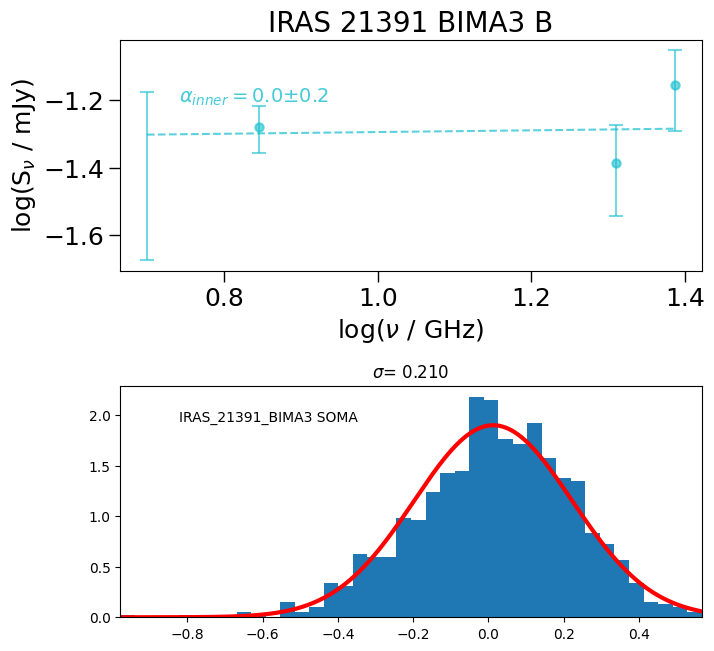

In [24]:
# Defined the pl parameters for the plot
pl.figure(figsize=(7.5,7.5))
ax1= pl.subplot(212)
ax2= pl.subplot(211)

# Here we defined the source and the component we want to make the SEDs from the SOMA_Radio_data_table_core_v3.txt table
source = 'IRAS_21391_BIMA3'
comp = 'B'

# Run the get_radio_flux and two functions from def_seds
freq, flux, fluxerr = get_radio_flux(source, comp=comp)
 
print(freq)
print(flux)
print(fluxerr)

plot_radio_flux(freq, flux, fluxerr, source, scale='core',color='tab:cyan', comp=comp)

pComp, pComp_err = fit_and_plot_alpha(freq, flux, fluxerr, doPlot= True, text_offset=0.1 ,alpha_text='inner', color='tab:cyan', source=source, ax1=ax1)
print(pComp[1], pComp_err)

pl.ylabel(r'log(S$_{\nu}$ / mJy)', fontsize=18)
pl.xlabel(r'log(${\nu}$ / GHz)', fontsize=18)
pl.tick_params('both', length=8, width=1, which='major', labelsize=11)
pl.tick_params('both', length=3, width=1, which='minor', labelsize=11)
pl.tick_params(labelsize=18)
pl.title(source.replace('-','$-$').replace('+','$+$').replace('_',' ')+' '+comp, fontsize=20)
pl.subplots_adjust(hspace=0.5)
pl.show()
pl.close()

### Spectral Index HII Contour

std allpnew=0.2596461366738896
ne not taking into account the limits (nd) in the flux [9082.14735374] [False, False, False, False]
ne taking into accounts nd in the flux [9082.14735374] [True, True, False, False]
Spherical Fixed size fit
A fit EM/1e7=0.0117 [pc cm**-6], n/1e4=0.9082 [cm**-3], s=1.416e-03 [pc]
ne not taking into account the limits (nd) in the flux 1065458659.320925
ne taking into accounts nd in the flux 1534347049.4067883
Spherical Free size fit
A fit EM/1e7=7328811.4165 [pc cm**-6], n/1e4=153434.7049 [cm**-3], s=3.113e-05 [pc]
3271.280651392002 6.344417086591664
1534347049.4067883 3.113051759954681e-05


/var/folders/cx/ltcvfstn1lz3r148g5xgn3880000gn/T/ipykernel_98510/2646524316.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('A fit EM/1e7=%.4f [pc cm**-6], n/1e4=%.4f [cm**-3], s=%.3e [pc]'%(EM_fitA_sphe/1e7,  ne_fitA_sphe/1e4, s_A))
/var/folders/cx/ltcvfstn1lz3r148g5xgn3880000gn/T/ipykernel_98510/2179152972.py:107: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  hits = np.where( tau_nu < 1e-3 )


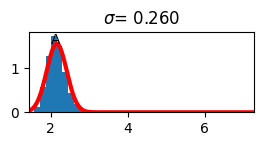

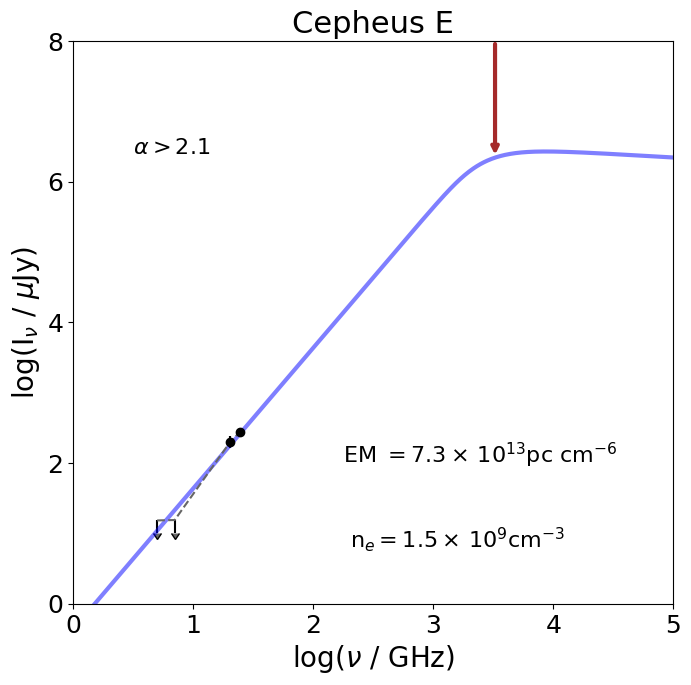

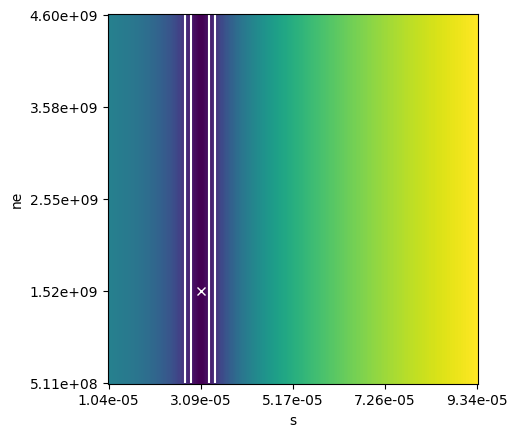

In [4]:
# Figure 1 will hold histograms
ax1=pl.subplot(421)
mygray='#666666'

# Component CepE
fluxA= np.array([15.3, 15.5, 202., 276.])   ## values from one box uJy
fluxAerr= np.array([5.1, 5.2, 35., 33.])    ## values from one box uJy
fluxAerr, fluxAlog, fluxAerrlog, fluxAerrlogpos, fluxAerrlogneg = log_calc(fluxA, fluxAerr)

#In order to plot the errors
fluxAerrlogpos[0]=0
fluxAerrlogpos[1]=0

fluxA_lim = [True if (x==0) else False for x in fluxAerrlogpos]

nu = np.array([5.0,7.0,20.4,24.4]) #GHz
nulog = np.log10(nu)

# Third method
pA, pA_err = curve_and_bootstrap(nu, fluxA, fluxAerr, doPlot=True, histAxis=ax1, histLabel='A')

### HII region fit:
D = 0.73*1000           # Distance to source pc
s_A_arc = 0.4           # convolved size (Beam size)
s_A = D*s_A_arc/206265  #[pc]
s = s_A                 # dummy number

nu_model_data = np.logspace(-2.3, 5, 1000)  # 1 to 30 GHz

ne_fitA_sphe = fit_HII_sphe_fit(nu, fluxA, fluxAerr, [False]*len(fluxA), D, s=s_A, Te=1e4)
print('ne not taking into account the limits (nd) in the flux', ne_fitA_sphe, [False]*len(fluxA))
ne_fitA_sphe = fit_HII_sphe_fit(nu, fluxA, fluxAerr, fluxA_lim, D, s=s_A, Te=1e4)
print('ne taking into accounts nd in the flux', ne_fitA_sphe, fluxA_lim)

S_fitA_sphe, EM_fitA_sphe = calc_S_therm_sphe_fit(nu_model_data, ne=ne_fitA_sphe, s=s_A, D=D, Te=1e4)

print('Spherical Fixed size fit')
print('A fit EM/1e7=%.4f [pc cm**-6], n/1e4=%.4f [cm**-3], s=%.3e [pc]'%(EM_fitA_sphe/1e7,  ne_fitA_sphe/1e4, s_A))


### SEDS spectra with the tau arrow + EM and ne
pl.figure(2, figsize=(7.5,7.5))
fig2=pl.gcf()
ax1 = fig2.add_axes([.15,.15, .8, .75])

pl.errorbar(nulog,fluxAlog,yerr=[fluxAerrlogneg,fluxAerrlogpos], ecolor='k',xerr=None, fmt='--', uplims=[1,1,0,0], color=mygray)
pl.errorbar(nulog[2:4],fluxAlog[2:4],yerr=[fluxAerrlogneg[2:4],fluxAerrlogpos[2:4]],xerr=None,fmt='ko')

pl.xlabel(r'log($\nu$ / GHz)', fontsize=20)
pl.ylabel(r'log(I$_{\nu}$ / $\mu$Jy)', fontsize=20)
pl.text(.1,0.8, r'$\alpha>$'+str(round(pA[1], 1)), transform=pl.gca().transAxes,fontsize=16,color='k')
pl.title(r'Cepheus E',fontsize=22)

pl.gca().set_xlim(0, 5)
pl.gca().set_ylim(0, 8)

pl.gcf().gca().xaxis.set_major_locator(MaxNLocator(5))
pl.gcf().gca().yaxis.set_major_locator(MaxNLocator(5))
pl.tick_params(labelsize=18)


nu_model_data = np.logspace(-2.3, 5, 1000)  # 1 to 30 GHz

ne_fitA_sphe, s_fitA_sphe = fit_HII_sphe_geo( nu, fluxA, fluxAerr, [False]*len(fluxA), D, Te=1e4 )
print('ne not taking into account the limits (nd) in the flux', ne_fitA_sphe)
ne_fitA_sphe, s_fitA_sphe = fit_HII_sphe_geo( nu, fluxA, fluxAerr, fluxA_lim, D, Te=1e4 )
print('ne taking into accounts nd in the flux', ne_fitA_sphe)

S_fitA_sphe, EM_fitA_sphe = calc_S_therm_sphe_geo(nu_model_data, ne=ne_fitA_sphe, s=s_fitA_sphe, D=D, Te=1e4 )

print('Spherical Free size fit')
print('A fit EM/1e7=%.4f [pc cm**-6], n/1e4=%.4f [cm**-3], s=%.3e [pc]'%(EM_fitA_sphe/1e7,  ne_fitA_sphe/1e4, s_fitA_sphe))

## HII region spherical
pl.plot(np.log10(nu_model_data), np.log10(S_fitA_sphe), '-b',linewidth=3, alpha=0.5)

## tau arrow
nu_tau = (3.28e-7 * EM_fitA_sphe)**(1./2.1)
S_tau_1,em_tau = calc_S_therm_sphe_geo( nu_tau, ne=ne_fitA_sphe, s=s_fitA_sphe, D=D, Te=1e4 )
pl.annotate('',xy=(np.log10( nu_tau ), np.log10( S_tau_1 )),xytext=(np.log10(nu_tau), 8), arrowprops=dict(arrowstyle='->',color='brown',lw=3))
print(nu_tau, np.log10( S_tau_1 ))

pl.text(.45,0.25,r'EM $=$'+ latex_float('%.1e' % EM_fitA_sphe) +'pc cm$^{-6}$',
        transform=pl.gca().transAxes,fontsize=16,color='k')
pl.text(.45,0.10,r' n${_e} = $'+ latex_float('%.1e' % ne_fitA_sphe) +'cm$^{-3}$',
        transform=pl.gca().transAxes,fontsize=16,color='k')


### Contours for the component --- Degenerative solution
range_factor = 3.0
range_size = 300
n_ticks = 5
tick_locs = np.linspace(0,range_size-1,n_ticks)

ne_range = np.linspace(ne_fitA_sphe/range_factor, ne_fitA_sphe*range_factor,range_size)
s_range = np.linspace(s_fitA_sphe/range_factor, s_fitA_sphe*range_factor,range_size)

contour_array = np.zeros((len(ne_range),len(s_range)))

print(ne_fitA_sphe, s_fitA_sphe)

ne_interp = interp1d( ne_range, range(len(ne_range)) )
s_interp = interp1d( s_range, range(len(s_range)) )

## units of ne and s[pc]
for i,ne in enumerate(ne_range):
    for j,s in enumerate(s_range):
        p_contour = [ne,s]
        contour_array[i,j] = calc_loglike( nu, fluxA, fluxAerr, fluxA_lim, p_contour, D, Te=1e4 )

contour_array = contour_array - np.min(contour_array)
fig3 = pl.figure(3)
pl.imshow(contour_array,origin='lower', interpolation='none')
pl.plot(s_interp(s_fitA_sphe), ne_interp(ne_fitA_sphe), 'wx')
pl.xlabel('s')
pl.ylabel('ne')
pl.contour(contour_array,levels=[0.5,1],colors='white')

fig3.gca().xaxis.set_ticks(tick_locs)
x_tick_labels = ['%.2e'%(s_range[int(x)]) for x in tick_locs]
fig3.gca().xaxis.set_ticklabels(x_tick_labels)

fig3.gca().yaxis.set_ticks(tick_locs)
y_tick_labels = ['%.2e'%(ne_range[int(x)]) for x in tick_locs]
fig3.gca().yaxis.set_ticklabels(y_tick_labels)
pl.show()

### Determine the Spectral Type from the Lyman continuum flux

In [5]:
# Run to read the beam size of the images to calculate the deconvolved size of the sources
# Path to the directory containing FITS files
folder_path = r'Images_FITS/Images_Radio_SOMAIII_fits'

# Loop through all files in the directory
for filename in os.listdir(folder_path):
    if filename.lower().endswith(".fits"):
        file_path = os.path.join(folder_path, filename)
        header = fits.getheader(file_path)
        beam = Beam.from_fits_header(header)

In [6]:
### Create the dictionaries for the sources, intensity could be rms if we are looking for limits or 
### flux intensity if is the characteristic spectral type of the source

### The columns are as follow: frequency (GHz), intensity (uJy), convolved size (arcsec), deconvolved size (arcsec), size (kpc)

# SOMA II Data - Limits
data_dict_SOMA_II = [{'nu': 5.0, 'S': 122.49904612, 'conv_size': 'NA', 'deconv_size': 0.26, 'dist': 7.4}, 
                     {'nu': 5.0, 'S': 3532.65733785, 'conv_size': 'NA', 'deconv_size': 1.09, 'dist': 5.5},
                     {'nu': 5.0, 'S': 33.07094652, 'conv_size': 'NA', 'deconv_size': 0.32, 'dist': 10.2},
                     {'nu': 5.0, 'S': 61.85198038, 'conv_size': 'NA', 'deconv_size': 2.49, 'dist': 1.7},
                     {'nu': 5.0, 'S': 47.5886192, 'conv_size': 'NA', 'deconv_size': 2.49, 'dist': 1.7},
                     {'nu': 5.0, 'S': 269.47172787, 'conv_size': 'NA', 'deconv_size': 0.97, 'dist': 4.1},
                     {'nu': 5.0, 'S': 546.51493383, 'conv_size': 'NA', 'deconv_size': 0.97, 'dist': 4.1},
                     {'nu': 5.0, 'S': 24.21445265, 'conv_size': 'NA', 'deconv_size': 0.29, 'dist': 5.55},
                     {'nu': 5.0, 'S': 74.56724397, 'conv_size': 'NA', 'deconv_size': 2.38, 'dist': 2.10}]

# SOMA III Data - Limits
data_dict_SOMA_III = [{'nu': 5.0, 'S': 29.46728738, 'conv_size': 'NA', 'deconv_size': 0.30, 'dist': 1.8}, 
                      {'nu': 5.0, 'S': 26.67756412, 'conv_size': 'NA', 'deconv_size': 0.59, 'dist': 0.764},
                      {'nu': 5.0, 'S': 72.48444738, 'conv_size': 'NA', 'deconv_size': 0.29, 'dist': 0.39},
                      {'nu': 5.0, 'S': 23.17234441, 'conv_size': 'NA', 'deconv_size': 0.33, 'dist': 0.73},
                      {'nu': 5.0, 'S': 32.84786441, 'conv_size': 'NA', 'deconv_size': 0.39, 'dist': 0.776},
                      {'nu': 5.0, 'S': 31.95033859, 'conv_size': 'NA', 'deconv_size': 0.39, 'dist': 0.776},
                      {'nu': 5.0, 'S': 42.97090413, 'conv_size': 'NA', 'deconv_size': 0.41, 'dist': 2.4},
                      {'nu': 5.0, 'S': 41.78573554, 'conv_size': 'NA', 'deconv_size': 0.41, 'dist': 2.4},
                      {'nu': 5.0, 'S': 45.41569187, 'conv_size': 'NA', 'deconv_size': 0.41, 'dist': 2.4},
                      {'nu': 5.0, 'S': 27.37839466, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75},
                      {'nu': 5.0, 'S': 31.80847923, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75},
                      {'nu': 5.0, 'S': 32.79085969, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75}]

# I21391 BIMA 2, 3 @6 cm
data_dict_C = [{'nu': 5.0, 'S': 233, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75}, # I21391 BIMA 2 A --- B3
               {'nu': 5.0, 'S': 194, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75}, # I21391 BIMA 2 C --- B4
               {'nu': 7.0, 'S': 21.6, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75}, # I21391 BIMA 2 B --- B3
               {'nu': 5.0, 'S': 14.0, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75}, # I21391 BIMA 3 A --- B3
               {'nu': 5.0, 'S': 36.0, 'conv_size': 'NA', 'deconv_size': 400, 'dist': 0.75}] # I21391 BIMA 3 B --- B4

# I21391 BIMA 2, 3 @1.3 cm
data_dict_K = [{'nu': 20.4, 'S': 644, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75},  # I21391 BIMA 2 A
               {'nu': 20.4, 'S': 45.1, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75}, # I21391 BIMA 2 C
               {'nu': 20.4, 'S': 106, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75},  # I21391 BIMA 2 C
               {'nu': 20.4, 'S': 304, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75},  # I21391 BIMA 3 A
               {'nu': 20.4, 'S': 41.0, 'conv_size': 'NA', 'deconv_size': 0.66, 'dist': 0.75}] # I21391 BIMA 3 B


# We run for the correspondent dictionary to estimante the Lyman continuum flux
for value in data_dict_C:
    print('Lyman Continuum Flux:', np.round(EM_calc(value),2))

Lyman Continuum Flux: 43.07
Lyman Continuum Flux: 42.99
Lyman Continuum Flux: 42.05
Lyman Continuum Flux: 41.85
Lyman Continuum Flux: 42.26
